# Entanglement Sudden Death

Entanglement is a fundamental feature of quantum mechanics. However, in the open quantum system, entanglement is very fragile due to the the decoherence caused by the interaction with the noisy environment. 

Entanglement Sudden Death refers to the abrupt disappearance of entanglement between two quantum systems due to decoherence within finite time. On the contrary, if entanglement gradually decreases to zero at infinite time, this is called asymptotic decay of entanglement. Whether ESD or asymptotic decay happens depends on the type of open quantum dynamics and the initial state. 

In order to quantify entanglement, we use Concurrence as our entanglement measure. Given a two-qubit density matrix $\rho$, we first define the spin-flipped state:

$$
\tilde{\rho}=(\sigma_y\otimes\sigma_y)\rho^*(\sigma_y\otimes\sigma_y) 
$$

Then we compute the eigenvalues $\lambda_1,\ \lambda_2,\ \lambda_3,\ \lambda_4$ of the matrix:

$$
R=\sqrt{\sqrt{\rho}\tilde{\rho}\sqrt{\rho}}
$$

We arrange the eigenvalues in decreasing order: $\lambda_1 \ge \lambda_2\ge \lambda_3\ge \lambda_4$, then the concurrence $C(\rho)$ is defined as:

$$
C(\rho)=\text{max}(0,\lambda_1-\lambda_2- \lambda_3- \lambda_4)
$$

If $C(\rho)>0$, then the state is entangled. If $C(\rho)=0$, then the state is separable.


## Setup

In [2]:
from math import ceil
import os
import json as json
import numpy as np
from tqdm import tqdm

from tenso.prototypes.heom import system_multibath
from tenso.prototypes.bath import gen_bcf
import matplotlib.pyplot as plt

## Bath Correlation Function (BCF)

In [3]:
bath = gen_bcf(
        re_d=[50.0], 
        width_d=[5],
        temperature=100,
        decomposition_method='Pade',
        n_ltc=1,
    )

## The Hamiltonians and the Initial State

In our example, we consider two qubits in an initially entangled state, each interacting with its own bosonic bath. The system Hamiltonian is given by:

$$
H_S=\frac{\omega_1}{2}\sigma_z+\frac{\omega_2}{2}\sigma_z
$$

We use $\sigma_x$ as the system operator for both qubits, which means the two-qubits experience amplitude-damping. Since each qubit interacts with its own bath and the baths are seperated and independent, the interaction Hamiltonian between the system and bath is given by:

$$
H_{SB}=\sigma_x^1\otimes \sum_jg_{1j}(a_{1j}+a_{1j}^\dagger)+\sigma_x^2\otimes \sum_jg_{2j}(a_{2j}+a_{2j}^\dagger)
$$

We start from a maximally entangled state: $$ \ket{\psi_0}=\frac{1}{\sqrt{2}}(\ket{01}+\ket{10})$$


In [8]:
# Define Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]], dtype=np.complex128)
sigma_z = np.array([[1, 0], [0, -1]], dtype=np.complex128)
I = np.eye(2, dtype=np.complex128)
# Define parameters
omega = 20  
# Define single qubit Hamiltonian
H1 = (omega / 2) * sigma_z + omega/2 * I
# Construct two-qubit Hamiltonian without interaction
h = np.kron(H1, I) + np.kron(I, H1)

Q_s1=np.array([[0.0, 0.5, 0, 0], [0.5, 0.0, 0, 0],[0.0, 0, 0, 0], [0, 0.0, 0, 0]], dtype=np.complex128)
Q_s2=np.array([[0.0, 0, 0, 0], [0, 0.0, 0, 0],[0.0, 0.5, 0, 0], [0.5, 0.0, 0, 0]], dtype=np.complex128)

sys_ops = [Q_s1,Q_s2] #The system Hamiltonian is sigma_z for both qubits 

rdo_0 = np.array([[0, 0, 0, 0],
                  [0, 0.5, -0.5, 0],
                  [0, -0.5, 0.5,0],
                  [0, 0, 0,0]],
                 dtype=np.complex128) #This is the initial state of the two-qubit system

## System-Multibath Propagator

**TENSO** provides the function `system_multibath()` to simulate open quantum systems in which different sites are coupled to distinct baths. This function gathers all parameters related to the system, the propagation scheme, and the influence of the baths on the system dynamics.

- `fname`: Specifies the output file name. In this example, it is `"2_qubit_esd"`, corresponding to the `out` variable.
- `init_rdo`: This defines the initial state of the system. In this example, the initial state is $\ket{\psi_0}=\frac{1}{\sqrt{2}}(\ket{01}+\ket{10})$
- `sys_ham`: The system Hamiltonian. In this example, the system Hamiltonian is given above.
- `sys_op`: The system operator ($Q_S$) entering the system-bath interaction Hamiltonian ($H_{SB}$). Each qubit couples to its own bath, so each qubit-bath coupling has its own system operator. `sys_op` should be a list of system operators where each system operator is associated to a qubit and a bath. In this example, the two elements are the same ($\sigma_x$). 
- `bath_correlation`: The bath correlation function (BCF) is a list of `bath` variables. In the list, each element is a seperated bath created by `get_bcf()`.
- `dim`: The hierarchy depth. Higher values of `dim` typically yield more accurate results.
- `end_time`: Final time of the simulation.
- `step_time`: Time step (`dt`) used for propagation.

`**tqdm**` is employed to display the progress bar during the simulation runtime.

In [ ]:
end_time = 1000.0
dt = 4

out = "2_qubit_esd"
propagator = system_multibath( 
        fname=out,
        init_rdo=rdo_0,
        sys_ham=h,
        sys_ops=sys_ops,
        bath_correlations=[bath] * 2, #Each qubit has its own bath, the two baths are seperated and independent
        end_time=end_time,
        step_time=dt,
        dim=20
    )

progress_bar = tqdm(propagator, total=ceil(end_time / dt)) #Show the progress bar
for _t in (progress_bar):
    progress_bar.set_description(f'@{_t:.2f} fs')

  0%|          | 0/250 [00:00<?, ?it/s]

{'auxiliary_ps_method': 'ps2', 'auxiliary_step_time': None, 'cache_svd_info': True, 'dim': 20, 'dvr_length': 32, 'dvr_type': 'sine', 'end_time': 1000.0, 'frame_method': 'tree2', 'load_checkpoint_from_file': False, 'max_auxiliary_rank': 64, 'max_auxiliary_steps': None, 'metric': 're', 'ode_atol': 1e-07, 'ode_method': 'dopri5', 'ode_rtol': 1e-05, 'ps2_atol': 1e-07, 'ps2_ratio': 2.0, 'ps_method': 'vmf', 'rank': 3, 'renormalize': False, 'save_checkpoint_to_file': False, 'start_time': 0.0, 'step_time': 4, 'stepwise_method': 'mix', 'use_dvr': False, 'visualize_frame': False, 'vmf_atol': 1e-07, 'vmf_reg_method': 'extend', 'vmf_reg_type': 'ip'}
For k=0: s:0.00694735 | e:0.00000000 | a:-0.00025000 | f:0.08335077 | f^2:0.00694735
For k=1: s:0.00032278 | e:0.00000000 | a:0.00000000 | f:0.01796598 | f^2:0.00032278
For k=0: s:0.00694735 | e:0.00000000 | a:-0.00025000 | f:0.08335077 | f^2:0.00694735
For k=1: s:0.00032278 | e:0.00000000 | a:0.00000000 | f:0.01796598 | f^2:0.00032278


@116.00 fs:  12%|█▏        | 30/250 [01:03<10:00,  2.73s/it]

Switched to vmf.


@996.00 fs: 100%|██████████| 250/250 [06:03<00:00,  1.46s/it]


## Plotting the Results

d:\Coding\Examples\ESD\Different_bath\Drude_Lorentz\Parameters\2_qubit_esd.dat.log


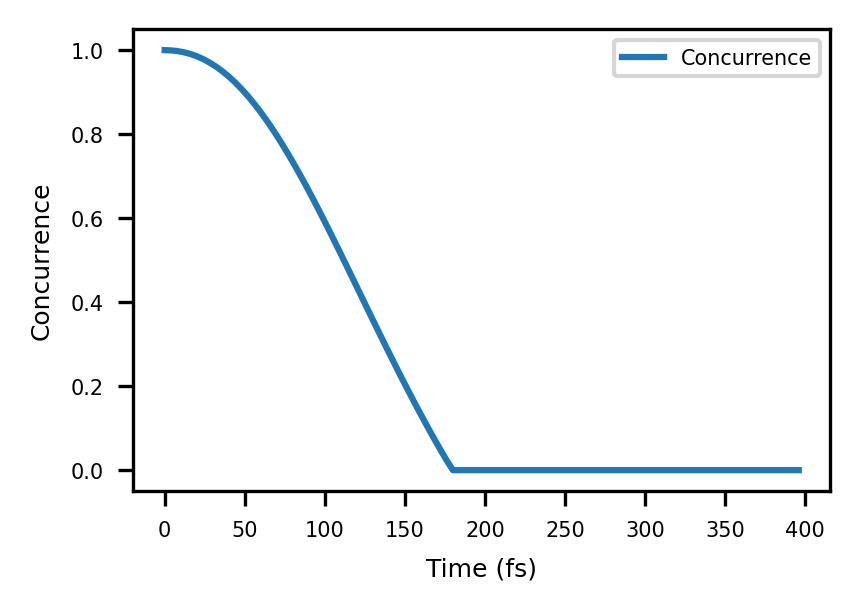

In [12]:
import matplotlib.pyplot as plt
from qutip import Qobj, concurrence

# Get the directory where the current script is located
current_dir = os.getcwd()
# Example: get relative path to A/data.log
log_path = os.path.join(current_dir, '2_qubit_esd.dat.log')

print(log_path)

data=np.loadtxt(log_path,dtype=complex)

cct=[]
t=[]
for i in range(data.shape[0]):
    rho_t=np.array([[data[i][1],data[i][2],data[i][3],data[i][4]],
                    [data[i][5],data[i][6],data[i][7],data[i][8]],
                    [data[i][9],data[i][10],data[i][11],data[i][12]],
                    [data[i][13],data[i][14],data[i][15],data[i][16]]])
    Ct = concurrence(Qobj(rho_t, dims=[[2, 2], [2, 2]]))
    cct.append(Ct)
    t.append(data[i][0])

fig=plt.figure(dpi=300,figsize=(3, 2))
plt.plot(t[:100],cct[:100],label="Concurrence")
plt.xlabel("Time (fs)")
plt.ylabel("Concurrence")
plt.legend()
plt.show()



## Influence of the Bath Temperature

In [ ]:
from qutip import Qobj, concurrence
import matplotlib.pyplot as plt

TT=[100,200,300,400]
for T in TT:
    print("T_%dK begins" % T)

    bath = gen_bcf(
        re_d=[200.0], 
        width_d=[50],
        temperature=T,
        decomposition_method='Pade',
        n_ltc=1,
    )

    out = "T_%dK" % T
    propagator = system_multibath( 
        fname=out,
        init_rdo=rdo_0,
        sys_ham=h,
        sys_ops=sys_ops,
        bath_correlations=[bath] * 2, 
        end_time=end_time,
        step_time=dt,
        dim=20
    )

    progress_bar = tqdm(propagator, total=ceil(end_time / dt)) 
    for _t in (progress_bar):
        progress_bar.set_description(f'@{_t:.2f} fs')

    print("T_%dK is completed" % T)


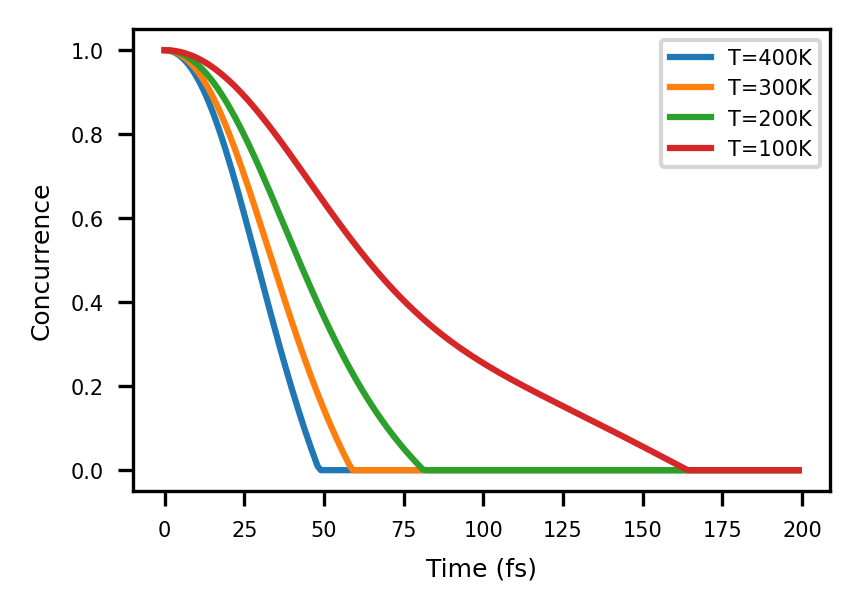

In [11]:
import matplotlib.pyplot as plt
from qutip import Qobj, concurrence

fig=plt.figure(dpi=300,figsize=(3, 2))
TT=[100,200,300,400]

for T in TT[::-1]:
    current_dir = os.getcwd()
    log_path = os.path.join(current_dir, "T_%dK.dat.log" % T)

    data=np.loadtxt(log_path,dtype=complex)

    cct=[]
    t=[]
    for i in range(data.shape[0]):
        rho_t=np.array([[data[i][1],data[i][2],data[i][3],data[i][4]],
                    [data[i][5],data[i][6],data[i][7],data[i][8]],
                    [data[i][9],data[i][10],data[i][11],data[i][12]],
                    [data[i][13],data[i][14],data[i][15],data[i][16]]])
        Ct = concurrence(Qobj(rho_t, dims=[[2, 2], [2, 2]]))
        cct.append(Ct)
        t.append(data[i][0])

    plt.plot(t,cct,label="T=%dK" % T)

plt.rcParams.update({
    "font.size": 4,          
    "axes.titlesize": 6,     
    "axes.labelsize": 6,     
    "xtick.labelsize": 5,    
    "ytick.labelsize": 5,    
    "legend.fontsize": 5,   
    "figure.titlesize": 7    
})
plt.xlabel("Time (fs)")
plt.ylabel("Concurrence")
plt.legend()
plt.show()

## Influence of the Bath Width

In this example, we consider a Drude-Lorentz spectral density:
$$
J(\omega) = \frac{2}{\pi} \frac{\lambda \omega \omega_c}{\omega_c^2 + \omega^2},
$$
where $\lambda$ is the reorganization energy and $\omega_c$ is the width of the bath.

In [ ]:
from qutip import Qobj, concurrence
import matplotlib.pyplot as plt

WW=[5,50,200,500]
for W in WW:
    print("W_%d begins" % W)

    bath = gen_bcf(
        re_d=[200.0], 
        width_d=[W],
        temperature=300,
        decomposition_method='Pade',
        n_ltc=1,
    )

    out = "W_%d" % W
    propagator = system_multibath( 
        fname=out,
        init_rdo=rdo_0,
        sys_ham=h,
        sys_ops=sys_ops,
        bath_correlations=[bath] * 2,
        end_time=end_time,
        step_time=dt,
        dim=20
    )

    progress_bar = tqdm(propagator, total=ceil(end_time / dt)) #Show the progress bar
    for _t in (progress_bar):
        progress_bar.set_description(f'@{_t:.2f} fs')

    print("W_%d is completed" % W)

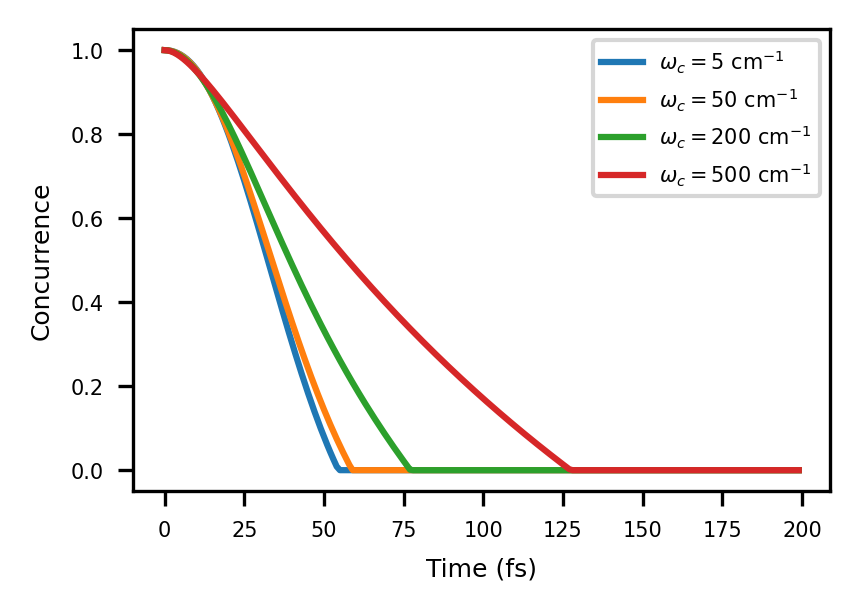

In [ ]:
fig=plt.figure(dpi=300,figsize=(3, 2))

WW=[5,50,200,500]
for W in WW[::]:
    current_dir = os.getcwd()
    log_path = os.path.join(current_dir, "W_%d.dat.log" % W)

    data=np.loadtxt(log_path,dtype=complex)

    cct=[]
    t=[]
    for i in range(data.shape[0]):
        rho_t=np.array([[data[i][1],data[i][2],data[i][3],data[i][4]],
                    [data[i][5],data[i][6],data[i][7],data[i][8]],
                    [data[i][9],data[i][10],data[i][11],data[i][12]],
                    [data[i][13],data[i][14],data[i][15],data[i][16]]])
        Ct = concurrence(Qobj(rho_t, dims=[[2, 2], [2, 2]]))
        cct.append(Ct)
        t.append(data[i][0])

    plt.plot(t,cct,label=r"$ \omega_c=%d \ \text{cm}^{-1}$" % W)

plt.xlabel("Time (fs)")
plt.ylabel("Concurrence")
plt.legend()
plt.show()